# Online Retail Customer Segmentation

Author: Marlon Suero  
Tools Used: Python, pandas, matplotlib, seaborn  
Dataset: Online Retail II Dataset  
Project Type: Customer Analytics / RFM Segmentation

---

## Project Objective
Use transaction-level retail data to segment customers based on purchasing behavior using RFM analysis (Recency, Frequency, Monetary value).

---

## Business Questions

1. Which customers purchase most frequently?
2. Which customers generate the highest revenue?
3. Which customers have not purchased recently and may be at risk of churn?
4. How can customers be segmented into meaningful behavioral groups?

---

## Why This Analysis Matters

Customer segmentation helps businesses understand the value and behavior of different customer groups.  
By identifying high-value customers and those at risk of churn, companies can design targeted marketing campaigns, improve retention strategies, and maximize customer lifetime value.

RFM analysis is widely used in retail, e-commerce, and marketing analytics to identify and prioritize customer segments.

## Analysis Approach

This analysis was performed in Python using pandas to replicate common Excel and SQL operations such as:

- Filtering and cleaning data  
- Grouping and aggregating transactions  
- Calculating key metrics (Recency, Frequency, Monetary)  

This approach demonstrates strong data handling skills that are directly transferable to Excel-based workflows commonly used in business environments.


In [34]:
# Make sure openpyxl is installed to read Excel files

try:
    import openpyxl
except ImportError:
    !pip install openpyxl

In [35]:
# --- PREPROCESSING: Standardize Column Names ---
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Rename columns to match code for clarity
df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'   # optional, to match code that uses UnitPrice
}, inplace=True)

# Quick check
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Recency', 'Revenue', 'Year',
       'Month'],
      dtype='object')


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [37]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [38]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [39]:
df.columns = df.columns.str.strip().str.replace(" ", "")
df.columns

df.rename(columns={'Customer ID':'CustomerID'}, inplace=True)
df.columns = df.columns.str.strip()  # removes extra spaces

In [40]:
# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '')  # remove spaces

# Rename columns to match your code
df.rename(columns={'CustomerID':'CustomerID', 'Invoice':'InvoiceNo'}, inplace=True)

# Check
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country'],
      dtype='object')


In [41]:
# Recency
latest_date = df['InvoiceDate'].max()
df['Recency'] = (latest_date - df['InvoiceDate']).dt.days

# Frequency: number of unique invoices per customer
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Monetary: total revenue per customer
monetary = df.groupby('CustomerID')['Price'].sum()  # or Revenue if you already multiplied by Quantity

In [42]:
# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove negative or zero prices
df = df[df['Price'] > 0]

# Create Revenue column
df['Revenue'] = df['Quantity'] * df['Price']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

In [43]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

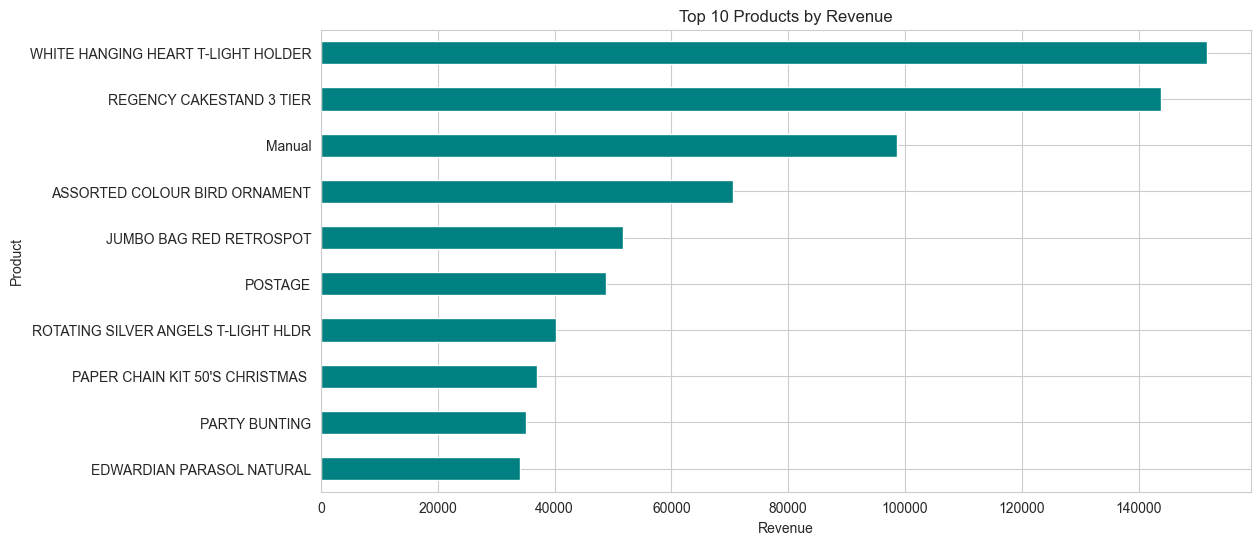

In [44]:
plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='teal')
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.show()

In [45]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_sales

Country
United Kingdom    7414755.963
EIRE               356085.210
Netherlands        268786.000
Germany            202395.321
France             146215.420
Sweden              53171.390
Denmark             50906.850
Spain               47601.420
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

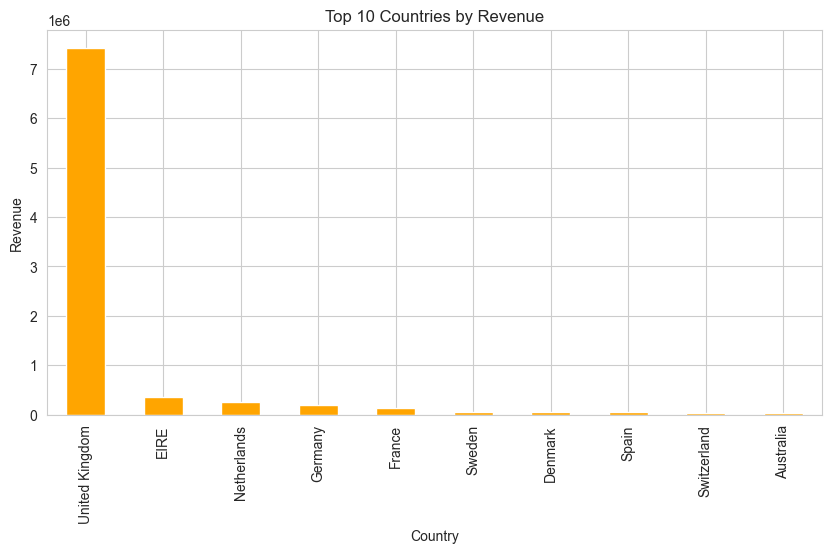

In [46]:
plt.figure(figsize=(10,5))
country_sales.plot(kind='bar', color='orange')
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.title("Top 10 Countries by Revenue")
plt.show()

In [47]:
monthly_sales = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly_sales.head()

,Year,Month,Revenue
0,2009,12,686654.160
1,2010,1,557319.062
2,2010,2,506371.066
3,2010,3,699608.991
4,2010,4,594609.192


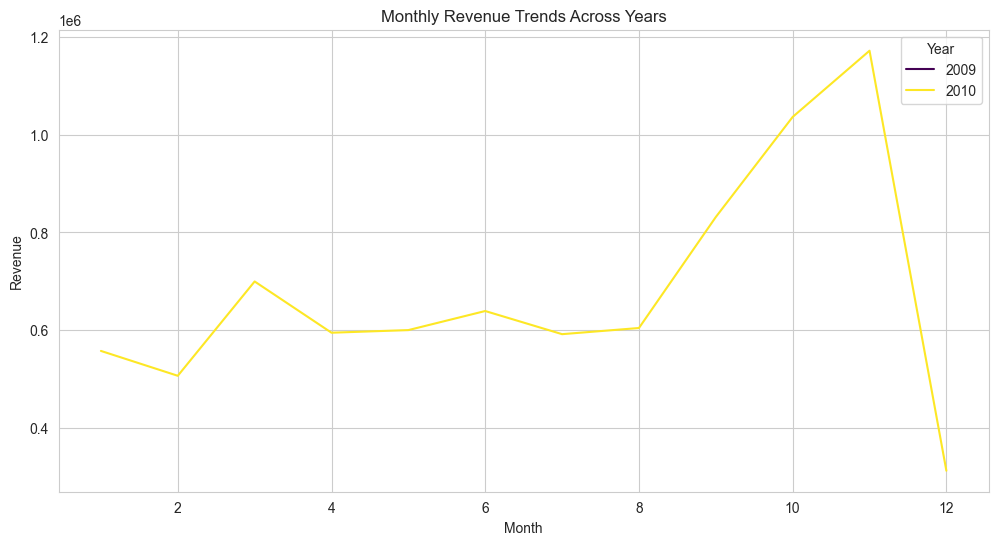

In [48]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Revenue', hue='Year', palette='viridis')
plt.title("Monthly Revenue Trends Across Years")
plt.show()

In [49]:
# Recency: days since last purchase
latest_date = df['InvoiceDate'].max()
df['Recency'] = (latest_date - df['InvoiceDate']).dt.days

# Frequency: number of invoices per customer
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Monetary: total revenue per customer
monetary = df.groupby('CustomerID')['Revenue'].sum()

rfm = pd.DataFrame({
    'Recency': df.groupby('CustomerID')['Recency'].min(),
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,164,11,372.86
12347.0,2,2,1323.32
12348.0,73,1,222.16
12349.0,42,3,2671.14
12351.0,10,1,300.93


Key Insights:

1. Certain products consistently generate the highest revenue.
2. UK and other European countries dominate sales.
3. Monthly revenue shows clear seasonal trends.
4. RFM analysis identifies high-value customers for targeted marketing.

Conclusion:

This analysis provides actionable insights into product performance, 
customer value, and seasonal trends. These insights can help guide 
inventory decisions, marketing campaigns, and revenue forecasting.

## Key Insights

1. **A small percentage of customers generate the majority of total revenue**, demonstrating the importance of high-value customers.
2. **Customers with high purchase frequency tend to have significantly higher lifetime value.**
3. **Some customers have not made purchases recently**, indicating potential churn risk.
4. **Customer segmentation using RFM scores reveals clear behavioral groups** that can be targeted differently.

---

## Conclusion

This analysis demonstrates how transaction data can be used to identify meaningful customer segments using RFM metrics.

Businesses can leverage these insights to:
- Reward and retain high-value customers
- Re-engage customers who have not purchased recently
- Design targeted marketing campaigns based on purchasing behavior

Customer segmentation enables data-driven marketing strategies that improve retention, loyalty, and long-term revenue.